# Preprocessing Text  
Terdapat 7 tahapan dalam preprocessing text yakni:  
1. Case Folding  
2. Remove Special Characters
3. Menghapus Angka
4. Menghapus Tanda Baca
5. Typo Correction
6. Tokenizing 
7. Stopword
8. Stemming  

Setelah itu dilakukan labeling data dengan 3 kelas yaitu positive, netral, dan negative dengan 2 kombinasi yaitu:
1. Labeling berdasarkan rating score
2. Labeling berdasarkan lexicon

## Import Library

In [36]:
import re
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from tqdm import tqdm
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from spellchecker import SpellChecker

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [17]:
data = pd.read_csv('data/data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  15000 non-null  object
 1   score    15000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 234.5+ KB


In [18]:
# Inisialisasi SpellChecker untuk Bahasa Inggris
spell = SpellChecker()

# Fungsi untuk spell checking menggunakan pyspellchecker
def correct_text_spellchecker(text):
    words = text.split()
    corrected_words = []
    for word in words:
        correction = spell.correction(word)
        corrected_words.append(correction if correction is not None else word)
    return ' '.join(corrected_words)

# Fungsi untuk normalisasi menggunakan kamus custom
def normalize_custom_kamus(text, kamus_dict):
    return ' '.join([kamus_dict.get(word, word) for word in text.split()])

# Fungsi untuk menghapus emoji
def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')


# --- Fungsi Preprocessing Lengkap ---
def preprocess(text, kamus_custom):
    # 1. Case Folding
    text = text.lower()
    
    # 2. Remove Emoji
    text = remove_emoji(text)

    # 3. Remove Special Characters
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 4. Menghapus Angka
    text = re.sub(r'\d+', '', text)
    
    # 5. Menghapus Tanda Baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Normalisasi Kata (Menggunakan Kamus Custom)
    text = normalize_custom_kamus(text, kamus_custom)

    # 7. Spell Checking
    text = correct_text_spellchecker(text)
    
    # 8. Tokenizing
    tokens = word_tokenize(text)
    
    # 9. Stopword Removal
    stopword_list = stopwords.words('english')
    tokens = [word for word in tokens if word not in stopword_list]
    
    # 10. Lemmatization 
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

# Fungsi untuk memuat kamus custom dari file
def load_custom_dictionary(filepath):
    custom_dict = {}
    with open(filepath, encoding='utf-8') as file:
        for line in file:
            if '=' in line:
                key, value = line.strip().split('=', 1)
                custom_dict[key.strip()] = value.strip()
    return custom_dict

# Load kamus custom
kamus_custom = load_custom_dictionary('kamus_custom_en.txt')

In [19]:
ulasan = "this game is amazing pls fix the bugs and add more features, thx :) 🤩"
processed_text = preprocess(ulasan, kamus_custom)
print(processed_text)

game amazing please fix bug add feature thanks


In [ ]:
tqdm.pandas()
# Terapkan fungsi preprocess ke seluruh data
data['clean_review'] = data['content'].astype(str).progress_apply(lambda x: preprocess(x, kamus_custom))

100%|██████████| 15000/15000 [1:40:18<00:00,  2.49it/s]   


In [21]:
# Cek hasilnya
print(data[['content', 'clean_review']].head())

                                             content  \
0  Basically a better and more intuitive version ...   
1  I like the game. It's programmed well and bugs...   
2  FIX MATCHMAKING. I cannot stand the one-sided ...   
3  The old Legend skins are completely outdated a...   
4  During matches, I consistently encounter a "re...   

                                        clean_review  
0  basically better intuitive version laughing lo...  
1  like game programmed well bug quite rare like ...  
2  fix matchmaking stand one sided skill matchmak...  
3  old legend skin completely outdated new epic s...  
4  match consistently encounter reconnecting issu...  


## Labeling Data

In [23]:
def label_from_score(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

# Terapkan ke dataset
data['label_score'] = data['score'].apply(label_from_score)

In [38]:
sia = SentimentIntensityAnalyzer()

def label_from_lexicon(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Terapkan ke kolom clean_review
data['label_lexicon'] = data['clean_review'].apply(label_from_lexicon)

In [39]:
data.head()

,content,score,clean_review,label_score,label_lexicon
0,Basically a better and more intuitive version ...,2,basically better intuitive version laughing lo...,negative,positive
1,I like the game. It's programmed well and bugs...,2,like game programmed well bug quite rare like ...,negative,positive
2,FIX MATCHMAKING. I cannot stand the one-sided ...,1,fix matchmaking stand one sided skill matchmak...,negative,neutral
3,The old Legend skins are completely outdated a...,2,old legend skin completely outdated new epic s...,negative,positive
4,"During matches, I consistently encounter a ""re...",1,match consistently encounter reconnecting issu...,negative,positive


## EDA

In [27]:
# Distribusi label berdasarkan score
print("Distribusi Label dari Kolom Score:")
print(data['label_score'].value_counts())

# Distribusi label berdasarkan lexicon
print("\nDistribusi Label dari Lexicon:")
print(data['label_lexicon'].value_counts())


Distribusi Label dari Kolom Score:
label_score
negative    9936
positive    3310
neutral     1754
Name: count, dtype: int64

Distribusi Label dari Lexicon:
label_lexicon
positive    9192
negative    5401
neutral      407
Name: count, dtype: int64


C:\Users\ANDIK\AppData\Local\Temp\ipykernel_23524\1802813020.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='label_score', palette='viridis')
C:\Users\ANDIK\AppData\Local\Temp\ipykernel_23524\1802813020.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='label_lexicon', palette='coolwarm')


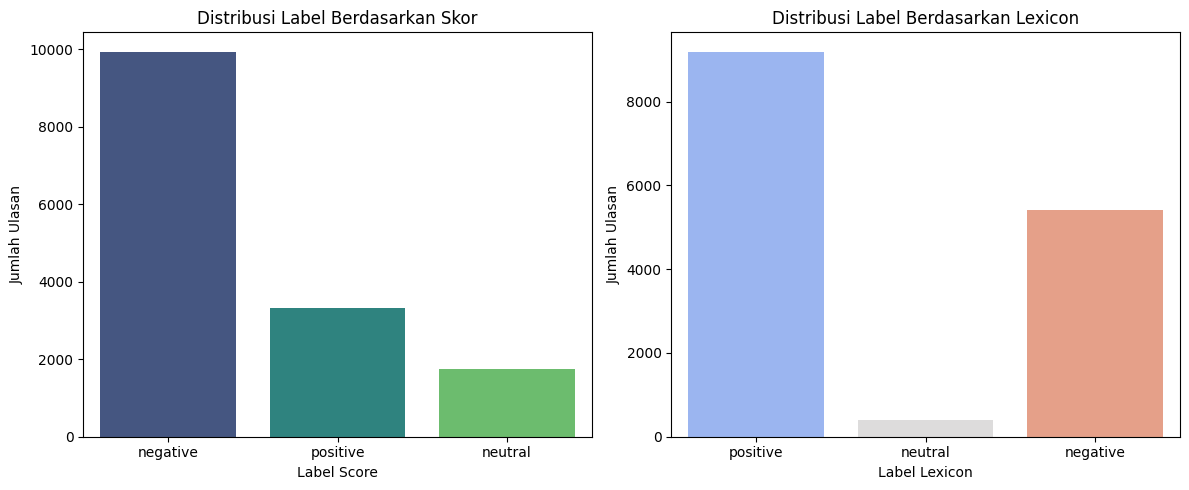

In [ ]:
# Barplot untuk label_score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=data, x='label_score', palette='viridis')
plt.title('Distribusi Label Berdasarkan Skor')
plt.xlabel('Label Score')
plt.ylabel('Jumlah Ulasan')

# Barplot untuk label_lexicon
plt.subplot(1, 2, 2)
sns.countplot(data=data, x='label_lexicon', palette='coolwarm')
plt.title('Distribusi Label Berdasarkan Lexicon')
plt.xlabel('Label Lexicon')
plt.ylabel('Jumlah Ulasan')

plt.tight_layout()
plt.show()


In [ ]:
def show_wordcloud(data, title=None):
    text = ' '.join(data)
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          max_words=200, collocations=False).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    if title:
        plt.title(title, fontsize=16)
    plt.show()

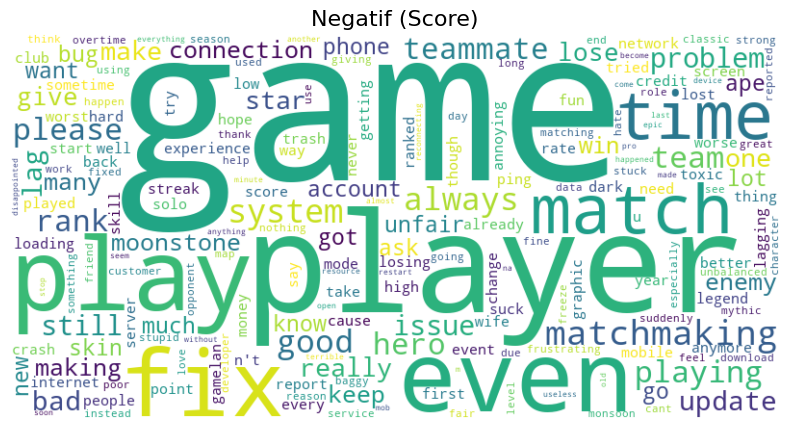

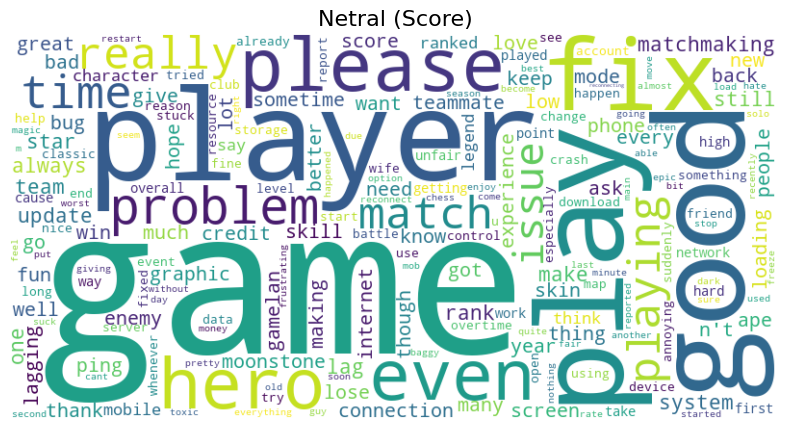

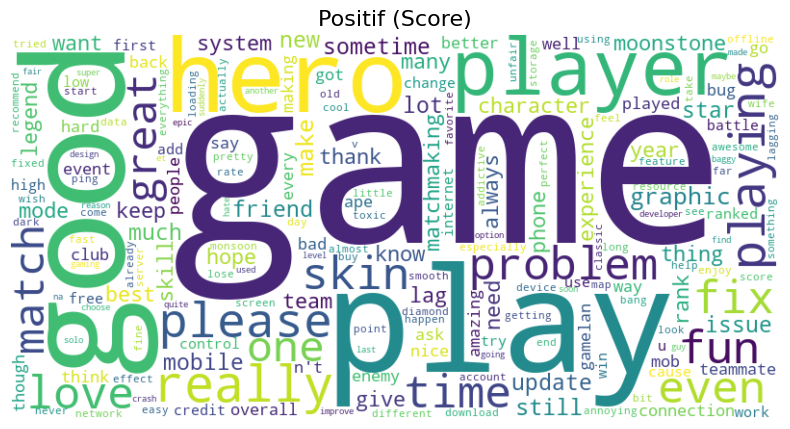

In [31]:
# Misal label_score: 1 = negatif, 2 = netral, 3 = positif

# Wordcloud untuk masing-masing label
show_wordcloud(data[data['label_score'] == 'negative']['clean_review'], title='Negatif (Score)')
show_wordcloud(data[data['label_score'] == 'neutral']['clean_review'], title='Netral (Score)')
show_wordcloud(data[data['label_score'] == 'positive']['clean_review'], title='Positif (Score)')


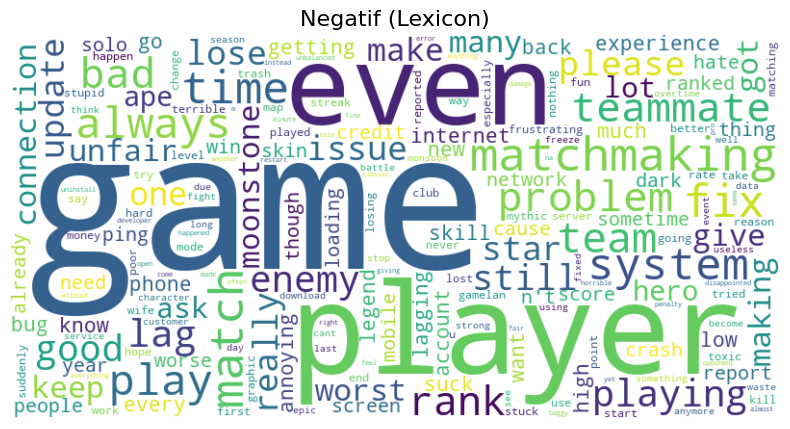

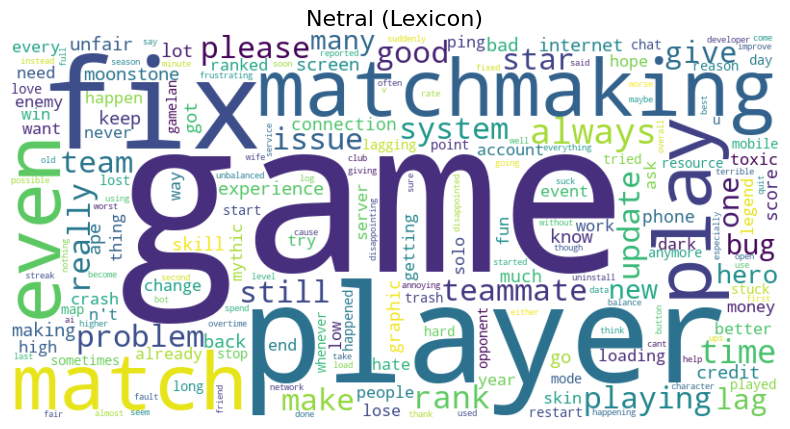

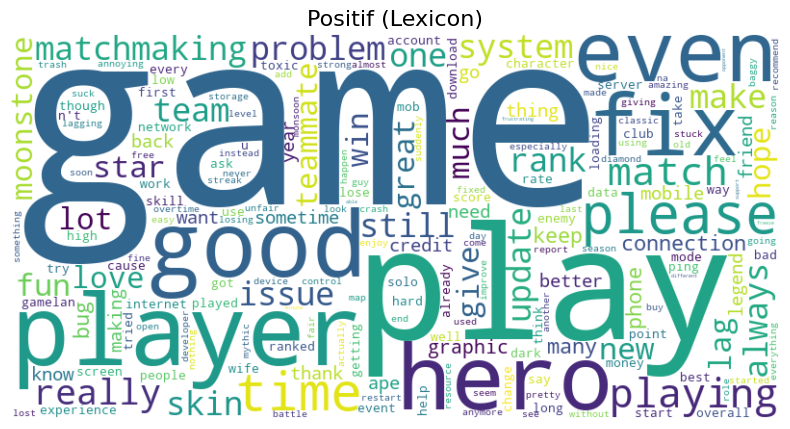

In [32]:
# Wordcloud untuk masing-masing label lexicon
show_wordcloud(data[data['label_lexicon'] == 'negative']['clean_review'], title='Negatif (Lexicon)')
show_wordcloud(data[data['label_lexicon'] == 'neutral']['clean_review'], title='Netral (Lexicon)')
show_wordcloud(data[data['label_lexicon'] == 'positive']['clean_review'], title='Positif (Lexicon)')

In [33]:
# Simpan data hasil preprocessing ke file baru (opsional)
data.to_csv('data/data_cleaned.csv', index=False)